In [ ]:
import os
from collections import defaultdict

# Path to your dataset folder
dataset_path = '/content/drive/MyDrive/Capstone/Deakin/furseal/task_datasets'

# Initialize dictionary to store class counts
class_counts = defaultdict(int)

# List files and count per class
for filename in os.listdir(dataset_path):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        class_prefix = filename[0].lower()  # 'a', 'b', etc.
        class_counts[class_prefix] += 1

# Sort and display results
sorted_counts = dict(sorted(class_counts.items()))
print("Class Distribution:")
for cls, count in sorted_counts.items():
    print(f"Class '{cls.upper()}': {count} images")


Class Distribution:
Class 'A': 7 images
Class 'B': 7 images
Class 'C': 7 images
Class 'D': 19 images
Class 'E': 10 images
Class 'F': 14 images
Class 'G': 3 images
Class 'H': 7 images


In [ ]:
import os
import cv2
import shutil
import random
import numpy as np
from collections import defaultdict
from pathlib import Path


# Paths
src_path = '/content/drive/MyDrive/Capstone/Deakin/furseal/task_datasets'
dst_path = '/content/drive/MyDrive/Capstone/Deakin/furseal/balanced_task_dataset'

# Create output directory
os.makedirs(dst_path, exist_ok=True)

# Organize filenames by class
class_images = defaultdict(list)
for fname in os.listdir(src_path):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        class_prefix = fname[0].lower()
        class_images[class_prefix].append(fname)

# Function to apply basic augmentations
def augment_image(img):
    augmented = []
    augmented.append(cv2.flip(img, 1))  # Horizontal flip
    augmented.append(cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE))
    augmented.append(cv2.convertScaleAbs(img, alpha=1.2, beta=30))  # Brighten
    augmented.append(cv2.convertScaleAbs(img, alpha=0.8, beta=-30))  # Darken
    return augmented

# Target images per class
target_per_class = 10

for cls, images in class_images.items():
    class_dir = os.path.join(dst_path, cls.upper())
    os.makedirs(class_dir, exist_ok=True)

    random.shuffle(images)
    src_images = images[:target_per_class] if len(images) >= target_per_class else images[:]

    # Copy original images (up to 10)
    for i, fname in enumerate(src_images):
        src_file = os.path.join(src_path, fname)
        dst_file = os.path.join(class_dir, f'{cls}_{i+1}.jpg')
        shutil.copy(src_file, dst_file)

    # Augment if less than target count
    if len(src_images) < target_per_class:
        needed = target_per_class - len(src_images)
        for i in range(needed):
            img_name = src_images[i % len(src_images)]
            img_path = os.path.join(src_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            aug_imgs = augment_image(img)
            aug_img = aug_imgs[i % len(aug_imgs)]
            aug_path = os.path.join(class_dir, f'{cls}_aug_{i+1}.jpg')
            cv2.imwrite(aug_path, aug_img)

print(" Balanced dataset created at:", dst_path)


 Balanced dataset created at: /content/drive/MyDrive/Capstone/Deakin/furseal/balanced_task_dataset


In [ ]:
#/content/drive/MyDrive/Capstone/Deakin/furseal/balanced_task_dataset/A
#/content/drive/MyDrive/Capstone/Deakin/furseal/balanced_task_dataset/B

In [ ]:
# Install segment-anything
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q opencv-python matplotlib

# Clone the SAM repository (optional for extra tools)
!git clone https://github.com/facebookresearch/segment-anything.git

# Download the SAM weights (ViT-H model)
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

# Import libraries
import torch
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
import cv2
from segment_anything import sam_model_registry, SamPredictor

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load SAM model
sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)


  Preparing metadata (setup.py) ... done
Cloning into 'segment-anything'...
remote: Enumerating objects: 304, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 304 (delta 2), reused 1 (delta 1), pack-reused 299 (from 2)
Receiving objects: 100% (304/304), 18.31 MiB | 32.44 MiB/s, done.
Resolving deltas: 100% (159/159), done.
--2025-04-21 10:12:12--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.163.189.96, 3.163.189.51, 3.163.189.108, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.163.189.96|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G   202MB/s    in 14s     

2025-04-21 10:12:26 (177 MB/s) - ‘sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



In [ ]:
import os

folder_path = '/content/drive/MyDrive/Capstone/Deakin/furseal/balanced_task_dataset/A'
print("Files in folder A:", os.listdir(folder_path))


Files in folder A: ['a_1.jpg', 'a_2.jpg', 'a_3.jpg', 'a_4.jpg', 'a_5.jpg', 'a_6.jpg', 'a_7.jpg', 'a_aug_1.jpg', 'a_aug_2.jpg', 'a_aug_3.jpg']


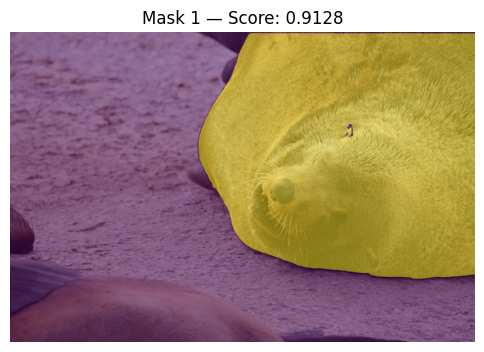

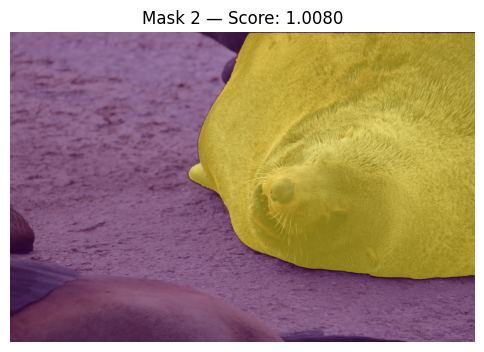

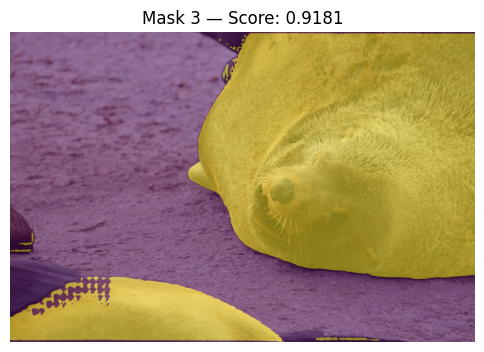

In [ ]:
import cv2
from PIL import Image

# Load one image to test from your dataset
image_path = '/content/drive/MyDrive/Capstone/Deakin/furseal/balanced_task_dataset/A/a_1.jpg'
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Set image for SAM
predictor.set_image(image_rgb)

# Helper function to click on the central seal (for now, we manually define the point)
# Example: You can adjust this to be more dynamic later
input_point = np.array([[image.shape[1] // 2, image.shape[0] // 2]])  # center of image
input_label = np.array([1])

# Predict mask
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

# Display masks
for i, mask in enumerate(masks):
    plt.figure(figsize=(6, 6))
    plt.imshow(image_rgb)
    plt.imshow(mask, alpha=0.5)
    plt.title(f"Mask {i+1} — Score: {scores[i]:.4f}")
    plt.axis('off')
    plt.show()


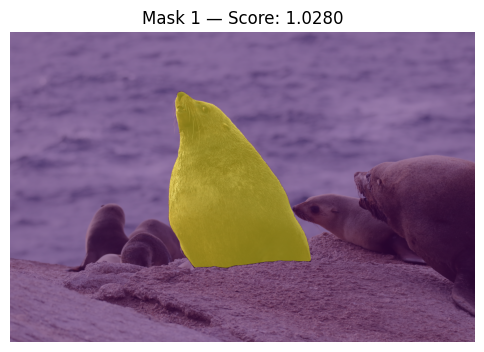

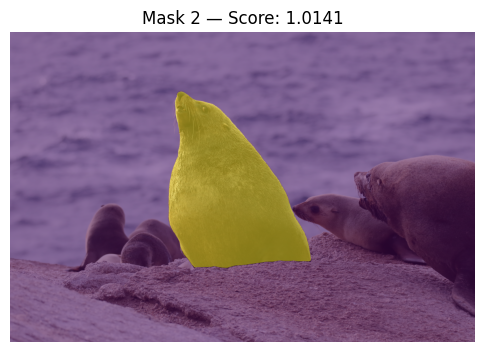

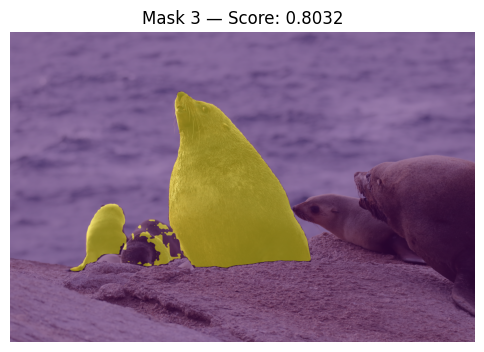

In [ ]:
import cv2
from PIL import Image

# Load one image to test from your dataset
image_path = '/content/drive/MyDrive/Capstone/Deakin/furseal/balanced_task_dataset/H/h_1.jpg'
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Set image for SAM
predictor.set_image(image_rgb)

# Helper function to click on the central seal (for now, we manually define the point)
# Example: You can adjust this to be more dynamic later
input_point = np.array([[image.shape[1] // 2, image.shape[0] // 2]])  # center of image
input_label = np.array([1])

# Predict mask
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

# Display masks
for i, mask in enumerate(masks):
    plt.figure(figsize=(6, 6))
    plt.imshow(image_rgb)
    plt.imshow(mask, alpha=0.5)
    plt.title(f"Mask {i+1} — Score: {scores[i]:.4f}")
    plt.axis('off')
    plt.show()


In [ ]:
import os

def apply_mask_and_save(image_rgb, mask, output_path):
    # Make binary mask
    binary_mask = mask.astype(np.uint8) * 255

    # Apply mask
    masked_image = cv2.bitwise_and(image_rgb, image_rgb, mask=binary_mask)

    # Save result
    cv2.imwrite(output_path, cv2.cvtColor(masked_image, cv2.COLOR_RGB2BGR))


In [ ]:
from tqdm import tqdm

input_root = '/content/drive/MyDrive/Capstone/Deakin/furseal/balanced_task_dataset'
output_root = '/content/drive/MyDrive/Capstone/Deakin/furseal/masked_dataset'

os.makedirs(output_root, exist_ok=True)

# Sort class folders and ignore system files
class_folders = sorted([d for d in os.listdir(input_root) if not d.startswith('.')])

for class_name in class_folders:
    class_input_dir = os.path.join(input_root, class_name)
    class_output_dir = os.path.join(output_root, class_name)  # just use same name like A, B, C

    os.makedirs(class_output_dir, exist_ok=True)

    for filename in tqdm(os.listdir(class_input_dir), desc=f'Processing {class_name}'):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')) and not filename.startswith('.'):
            image_path = os.path.join(class_input_dir, filename)
            image = cv2.imread(image_path)
            if image is None:
                print(f"Failed to read: {image_path}")
                continue
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Set image for SAM
            predictor.set_image(image_rgb)

            # Center click
            input_point = np.array([[image.shape[1] // 2, image.shape[0] // 2]])
            input_label = np.array([1])

            # Predict mask
            masks, scores, _ = predictor.predict(
                point_coords=input_point,
                point_labels=input_label,
                multimask_output=True,
            )

            # Best mask
            best_mask_idx = np.argmax(scores)
            best_mask = masks[best_mask_idx]

            # Save masked image
            output_path = os.path.join(class_output_dir, filename)
            apply_mask_and_save(image_rgb, best_mask, output_path)


Processing H: 100%|██████████| 10/10 [00:34<00:00,  3.49s/it]


In [ ]:
!pip install -q albumentations


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import random

def augment_and_save(image, output_path_base, count=3):
    transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.Rotate(limit=20, p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.4),
    ])

    for i in range(count):
        augmented = transform(image=image)
        aug_img = augmented['image']
        aug_path = f"{output_path_base}_aug_{i+1}.jpg"
        cv2.imwrite(aug_path, cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))


In [ ]:
from tqdm import tqdm

masked_root = '/content/drive/MyDrive/Capstone/Deakin/furseal/masked_dataset'
augmented_root = '/content/drive/MyDrive/Capstone/Deakin/furseal/augmented_dataset'

os.makedirs(augmented_root, exist_ok=True)

for class_name in sorted(os.listdir(masked_root)):
    input_dir = os.path.join(masked_root, class_name)
    output_dir = os.path.join(augmented_root, class_name)
    os.makedirs(output_dir, exist_ok=True)

    for filename in tqdm(os.listdir(input_dir), desc=f"Augmenting {class_name}"):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')) and not filename.startswith('.'):
            input_path = os.path.join(input_dir, filename)
            image = cv2.imread(input_path)
            if image is None:
                print(f"Failed to load: {input_path}")
                continue
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Save original
            base_filename = os.path.splitext(filename)[0]
            cv2.imwrite(os.path.join(output_dir, filename), image)

            # Augment and save
            output_base = os.path.join(output_dir, base_filename)
            augment_and_save(image_rgb, output_base, count=3)


Augmenting A:   0%|          | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
Augmenting H: 100%|██████████| 10/10 [00:12<00:00,  1.28s/it]


In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import os


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
data_dir = '/content/drive/MyDrive/Capstone/Deakin/furseal/augmented_dataset'

dataset = ImageFolder(data_dir, transform=transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

class_names = dataset.classes
print("Classes:", class_names)


Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(class_names))  # Adapt to number of seal IDs
model = model.to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 158MB/s]


In [ ]:
# Optional: Add class weights if dataset is unbalanced
# class_counts = [len(os.listdir(os.path.join(data_dir, c))) for c in class_names]
# weights = 1. / torch.tensor(class_counts, dtype=torch.float)
# class_weights = weights.to(device)
# criterion = nn.CrossEntropyLoss(weight=class_weights)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss, correct = 0.0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = 100 * correct / train_size
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/train_size:.4f}, Accuracy: {train_acc:.2f}%")


Epoch [1/10], Loss: 1.5877, Accuracy: 50.78%
Epoch [2/10], Loss: 0.4536, Accuracy: 95.31%
Epoch [3/10], Loss: 0.1587, Accuracy: 98.05%
Epoch [4/10], Loss: 0.0615, Accuracy: 99.61%
Epoch [5/10], Loss: 0.0302, Accuracy: 99.61%
Epoch [6/10], Loss: 0.0284, Accuracy: 99.61%
Epoch [7/10], Loss: 0.0378, Accuracy: 100.00%
Epoch [8/10], Loss: 0.0559, Accuracy: 98.44%
Epoch [9/10], Loss: 0.0399, Accuracy: 99.22%
Epoch [10/10], Loss: 0.0320, Accuracy: 99.61%


In [ ]:
model.eval()
correct = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        correct += (outputs.argmax(1) == labels).sum().item()

val_acc = 100 * correct / val_size
print(f"Validation Accuracy: {val_acc:.2f}%")


Validation Accuracy: 95.31%


In [ ]:
model_path = "/content/drive/MyDrive/Capstone/Deakin/furseal/resnet50_furseal.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved at {model_path}")


Model saved at /content/drive/MyDrive/Capstone/Deakin/furseal/resnet50_furseal.pth


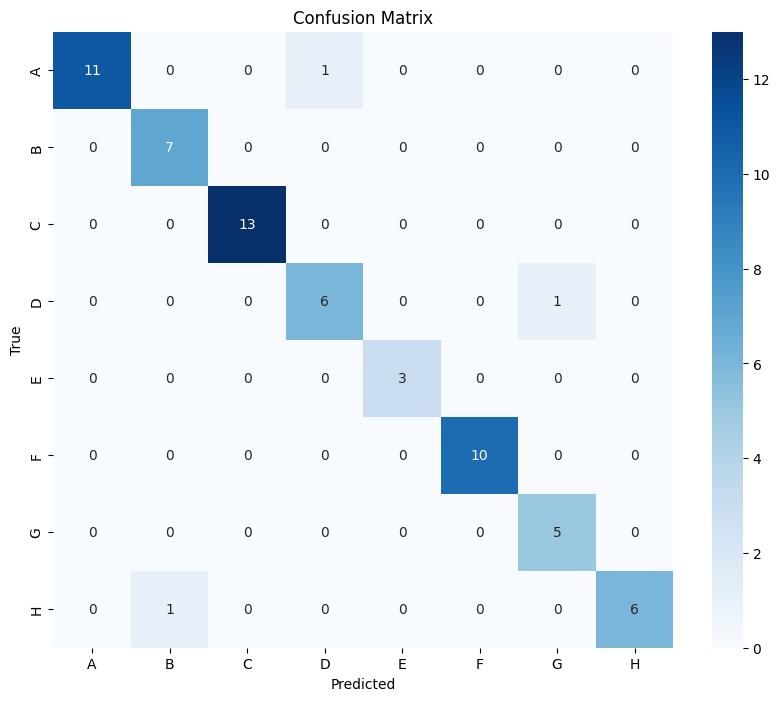

              precision    recall  f1-score   support

           A       1.00      0.92      0.96        12
           B       0.88      1.00      0.93         7
           C       1.00      1.00      1.00        13
           D       0.86      0.86      0.86         7
           E       1.00      1.00      1.00         3
           F       1.00      1.00      1.00        10
           G       0.83      1.00      0.91         5
           H       1.00      0.86      0.92         7

    accuracy                           0.95        64
   macro avg       0.95      0.95      0.95        64
weighted avg       0.96      0.95      0.95        64



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Gather predictions
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(all_labels, all_preds, target_names=class_names))


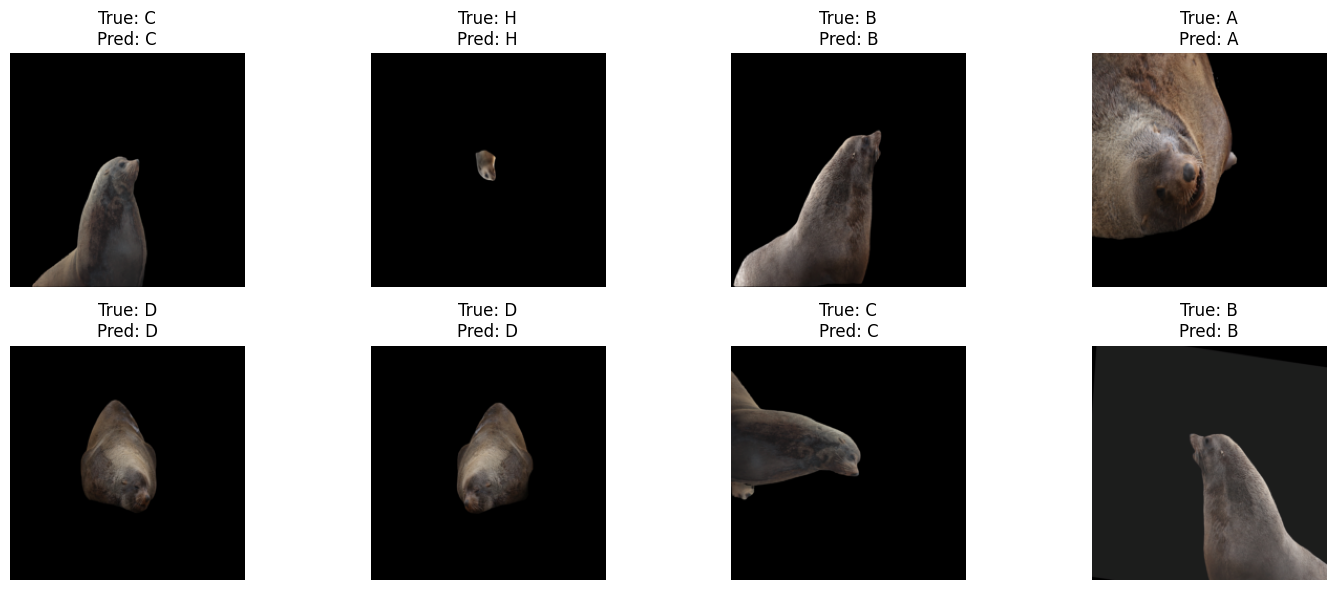

In [ ]:
def visualize_predictions(model, dataset, n=8):
    model.eval()
    fig, axs = plt.subplots(2, n//2, figsize=(15, 6))

    for i in range(n):
        img, label = dataset[i]
        with torch.no_grad():
            output = model(img.unsqueeze(0).to(device))
            pred = output.argmax(1).item()

        ax = axs[i//(n//2)][i%(n//2)]
        img_np = img.permute(1, 2, 0).numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)

        ax.imshow(img_np)
        ax.axis('off')
        ax.set_title(f'True: {class_names[label]}\nPred: {class_names[pred]}')

    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_dataset, n=8)


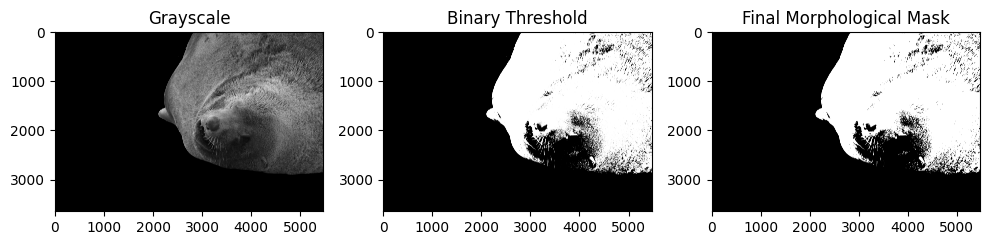

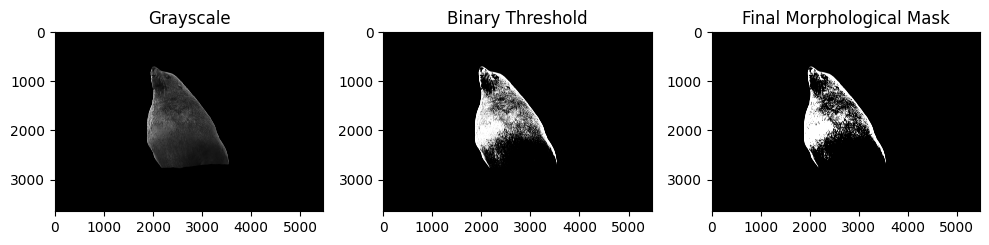

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Define the paths to the two images
image_paths = [
    '/content/drive/MyDrive/Capstone/Deakin/furseal/masked_dataset/A/a_1.jpg',
    '/content/drive/MyDrive/Capstone/Deakin/furseal/masked_dataset/H/h_1.jpg'
]

# Structuring element (kernel)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (4, 4))  # You can adjust size

def morphological_mask(image_path, save_path=None):
    # Step 1: Read image and convert to grayscale
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Step 2: Binary thresholding
    _, binary = cv2.threshold(gray, 50, 100, cv2.THRESH_BINARY)

    # Step 3: Morphological operations
    # Erosion followed by Dilation = Opening
    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # Dilation followed by Erosion = Closing
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

    # Optional: Save output mask
    if save_path:
        cv2.imwrite(save_path, closed)

    # Show result
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(gray, cmap='gray')
    plt.title('Grayscale')

    plt.subplot(1, 3, 2)
    plt.imshow(binary, cmap='gray')
    plt.title('Binary Threshold')

    plt.subplot(1, 3, 3)
    plt.imshow(closed, cmap='gray')
    plt.title('Final Morphological Mask')
    plt.tight_layout()
    plt.show()

    return closed

# Process both images
for path in image_paths:
    base_name = os.path.basename(path)
    output_path = f"/content/drive/MyDrive/Capstone/Deakin/furseal/morph_mask_{base_name}"
    morphological_mask(path, save_path=output_path)


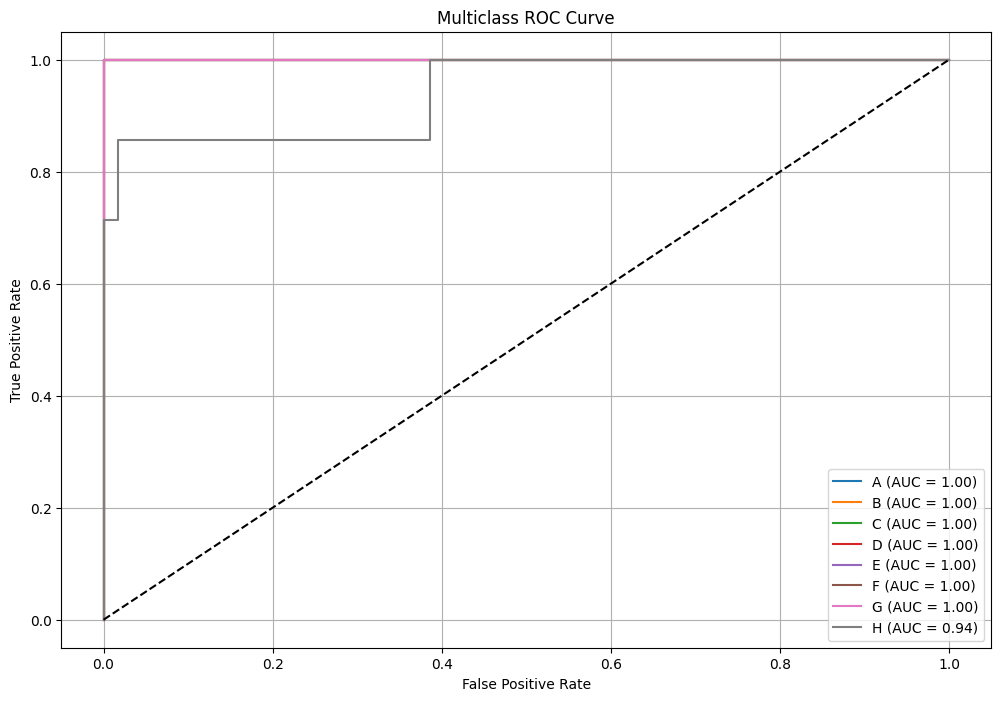

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import RocCurveDisplay

# Binarize labels for multiclass ROC
y_true_bin = label_binarize(all_labels, classes=list(range(len(class_names))))
y_scores = []

model.eval()
with torch.no_grad():
    for images, _ in val_loader:
        images = images.to(device)
        outputs = model(images)
        y_scores.append(outputs.cpu().numpy())

y_scores = np.concatenate(y_scores, axis=0)

# Plot ROC Curve for each class
fpr, tpr, roc_auc = {}, {}, {}
plt.figure(figsize=(12, 8))

for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Processing H: 100%|██████████| 10/10 [00:12<00:00,  1.24s/it]


Accuracy: 0.5625

Classification Report:
              precision    recall  f1-score   support

           A       1.00      0.60      0.75        10
           B       1.00      0.20      0.33        10
           C       0.62      1.00      0.77        10
           D       0.21      0.60      0.31        10
           E       1.00      0.50      0.67        10
           F       0.62      1.00      0.77        10
           G       1.00      0.10      0.18        10
           H       1.00      0.50      0.67        10

    accuracy                           0.56        80
   macro avg       0.81      0.56      0.56        80
weighted avg       0.81      0.56      0.56        80



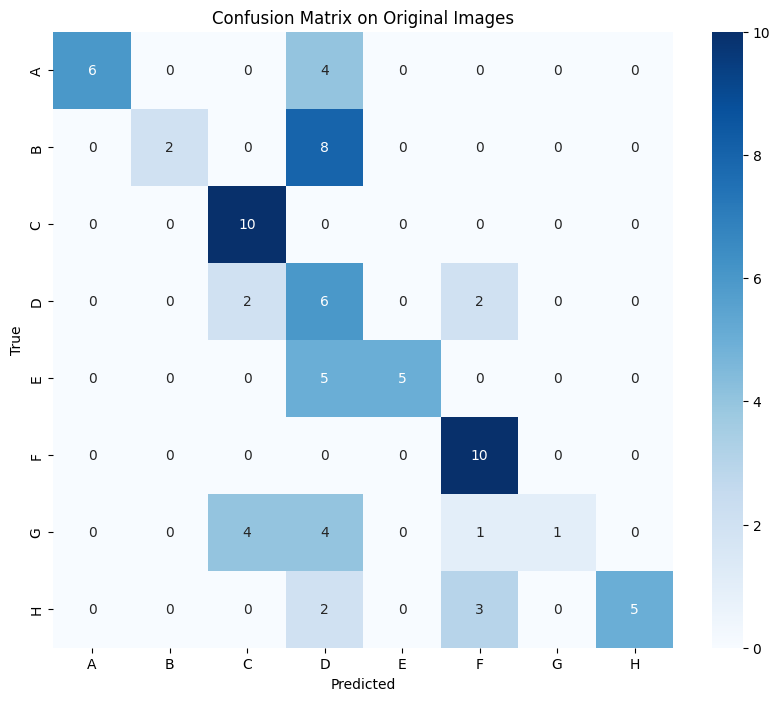

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

# Paths
model_path = "/content/drive/MyDrive/Capstone/Deakin/furseal/resnet50_furseal.pth"
data_dir = "/content/drive/MyDrive/Capstone/Deakin/furseal/balanced_task_dataset"

# Define class names based on folder structure
class_names = sorted(os.listdir(data_dir))
num_classes = len(class_names)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

# Transform (standard ImageNet normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Prepare data
y_true = []
y_pred = []

for class_idx, class_name in enumerate(class_names):
    class_dir = os.path.join(data_dir, class_name)
    image_files = [f for f in os.listdir(class_dir) if f.endswith('.jpg')]

    for image_file in tqdm(image_files, desc=f"Processing {class_name}"):
        img_path = os.path.join(class_dir, image_file)
        image = Image.open(img_path).convert("RGB")
        input_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            _, predicted = torch.max(output, 1)

        y_true.append(class_idx)
        y_pred.append(predicted.item())

# Evaluation
print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title("Confusion Matrix on Original Images")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


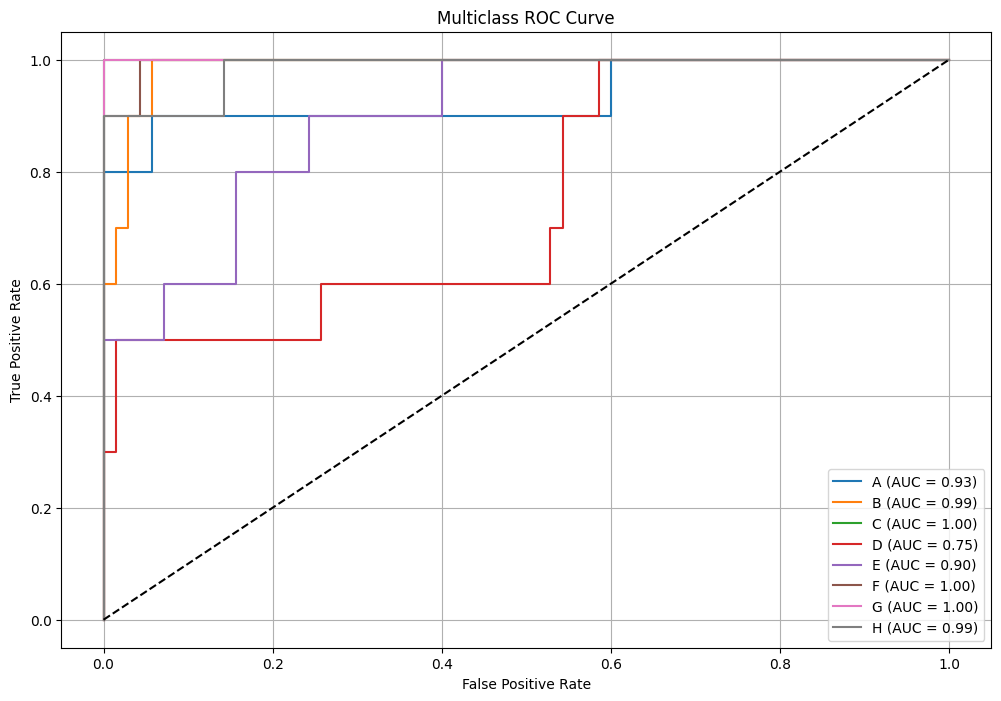

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the output for multiclass ROC-AUC
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
y_score = []

# Get prediction probabilities
model.eval()
for class_idx, class_name in enumerate(class_names):
    class_dir = os.path.join(data_dir, class_name)
    image_files = [f for f in os.listdir(class_dir) if f.endswith('.jpg')]

    for image_file in image_files:
        img_path = os.path.join(class_dir, image_file)
        image = Image.open(img_path).convert("RGB")
        input_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probs = torch.softmax(output, dim=1)
            y_score.append(probs.cpu().numpy())

y_score = np.vstack(y_score)

# Plot ROC Curve
plt.figure(figsize=(12, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Multiclass ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
print(12)

12


In [ ]:
import cv2
import numpy as np
import os
from tqdm import tqdm

# Input and output directories
input_root = "/content/drive/MyDrive/Capstone/Deakin/furseal/masked_dataset"
output_root = "/content/drive/MyDrive/Capstone/Deakin/furseal/morp_dataset"

# Structuring element (kernel)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (4, 4))

def morphological_mask(image_path, save_path):
    # Read image and convert to grayscale
    image = cv2.imread(image_path)
    if image is None:
        print(f"Image not found: {image_path}")
        return
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Binary thresholding
    _, binary = cv2.threshold(gray, 50, 100, cv2.THRESH_BINARY)

    # Morphological operations: Opening then Closing
    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

    # Save result
    cv2.imwrite(save_path, closed)

# Loop through all folders (A to H)
for subdir in sorted(os.listdir(input_root)):
    input_folder = os.path.join(input_root, subdir)
    output_folder = os.path.join(output_root, subdir)

    # Skip if not a directory
    if not os.path.isdir(input_folder):
        continue

    # Create output directory if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)

    print(f"Processing {subdir}:")
    for img_file in tqdm(os.listdir(input_folder)):
        input_path = os.path.join(input_folder, img_file)
        output_path = os.path.join(output_folder, img_file)

        morphological_mask(input_path, output_path)


Processing A:


100%|██████████| 10/10 [00:17<00:00,  1.73s/it]


Processing B:


100%|██████████| 10/10 [00:16<00:00,  1.68s/it]


Processing C:


...

100%|██████████| 10/10 [00:19<00:00,  1.91s/it]


Processing G:


100%|██████████| 10/10 [00:18<00:00,  1.82s/it]


Processing H:


100%|██████████| 10/10 [00:13<00:00,  1.31s/it]


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Paths
data_dir = "/content/drive/MyDrive/Capstone/Deakin/furseal/morp_dataset"
model_save_path = "/content/drive/MyDrive/Capstone/Deakin/furseal/resnet50_furseal_morph.pth"

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Dataset & DataLoader
dataset = datasets.ImageFolder(data_dir, transform=transform)
class_names = dataset.classes
num_classes = len(class_names)

# Split into train/val
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

# Load Pretrained ResNet
model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Train
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

# Save model
torch.save(model.state_dict(), model_save_path)
print(f"Model saved at {model_save_path}")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 96.2MB/s]


Epoch [1/10], Loss: 2.0254
Epoch [2/10], Loss: 1.2296
Epoch [3/10], Loss: 0.7641
Epoch [4/10], Loss: 0.4219
Epoch [5/10], Loss: 0.2460
Epoch [6/10], Loss: 0.1178
Epoch [7/10], Loss: 0.0726
Epoch [8/10], Loss: 0.0404
Epoch [9/10], Loss: 0.0287
Epoch [10/10], Loss: 0.0221
Model saved at /content/drive/MyDrive/Capstone/Deakin/furseal/resnet50_furseal_morph.pth


Classification Report:

              precision    recall  f1-score   support

           A       0.50      1.00      0.67         2
           B       1.00      1.00      1.00         2
           C       1.00      0.50      0.67         2
           D       1.00      1.00      1.00         1
           E       1.00      1.00      1.00         1
           F       1.00      0.33      0.50         3
           G       0.50      1.00      0.67         2
           H       1.00      0.67      0.80         3

    accuracy                           0.75        16
   macro avg       0.88      0.81      0.79        16
weighted avg       0.88      0.75      0.74        16



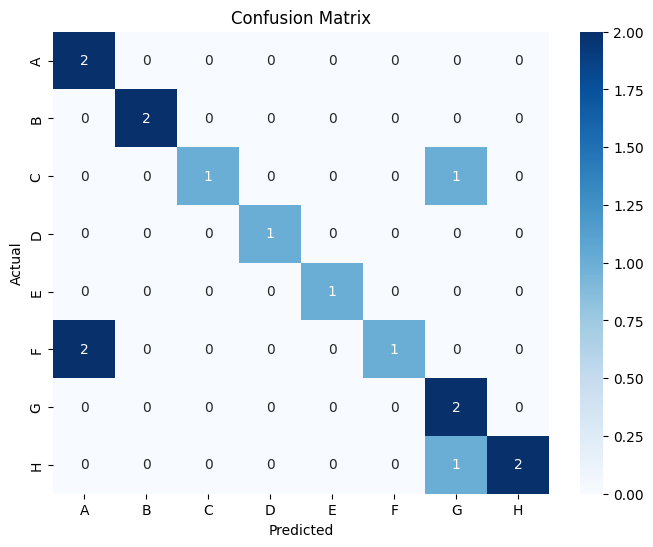

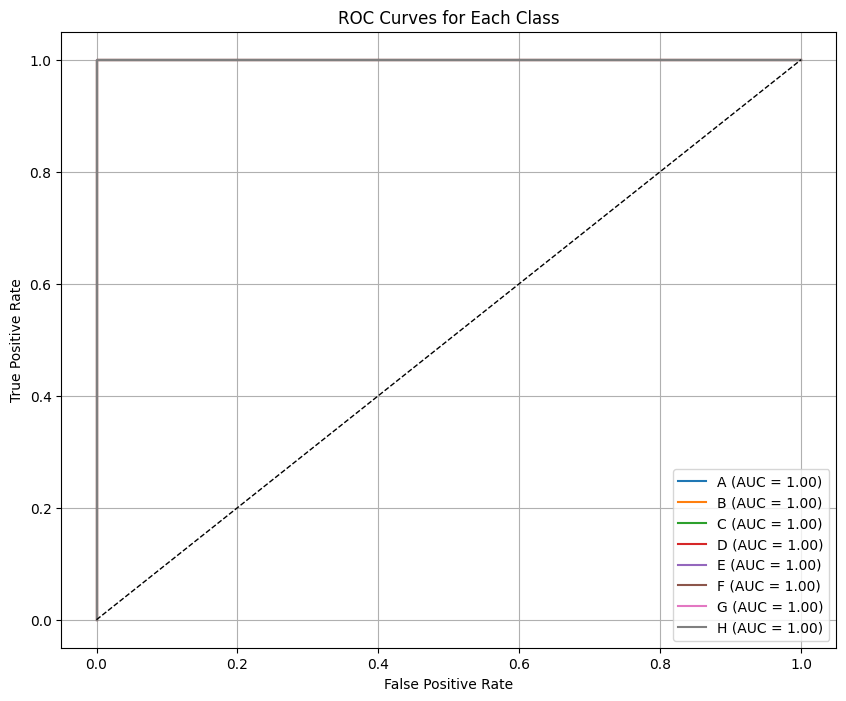

In [ ]:
# Evaluation
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Classification report
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve & AUC
y_true = np.eye(num_classes)[all_labels]
y_scores = np.array(all_probs)

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
